# When an Attractive Backtest Is Still the Wrong Rule to Trade

**A broad trend rule looked attractive in the historical record—even against a portfolio with the same average leverage. But it was usually leveraged, and none of six genuinely occasional designs passed the consistency screen.**

The starting portfolio holds **U.S. stocks (VTI, 30%)**, **long-term U.S. Treasuries (TLT, 40%)**, **intermediate-term U.S. Treasuries (IEF, 15%)**, **broad commodities (DBC, 7.5%)**, and **gold (GLD, 7.5%)**. The practical problem is whether rebalancing, cash reserves, drawdown responses, volatility controls, or trend-based leverage can improve that strategic allocation without creating a rule too fragile or impractical to trade.

The governing question is simple: **when an attractive realized backtest survives a same-average-leverage comparison, is the remaining advantage robust and implementable enough to become an operating policy?**

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
DATA_DIR = Path('data')
ASSETS = ['VTI', 'TLT', 'IEF', 'DBC', 'GLD']
WEIGHTS = pd.Series({'VTI': .30, 'TLT': .40, 'IEF': .15, 'DBC': .075, 'GLD': .075})
TC = 5 / 10_000
PRIMARY_END = pd.Timestamp('2025-12-31')
SAMPLE_SHORT = {'long_history': 'Long history', 'etf_era': 'ETF era'}
SAMPLE_FULL = {
    'long_history': 'Long-history proxy view (1993–2025)',
    'etf_era': 'ETF-era view (2010–2026)',
}
BASE_LABELS = {
    'PASSIVE': 'Let weights drift',
    'ANNUAL': 'Reset annually',
    'FULL_5PP': 'Reset after 5-point drift',
}


## Two real-data samples

The **long-history proxy view (1993–2025)** extends the analysis through asset-class proxy returns. The **ETF-era view (2010–2026)** uses investable ETF histories. Below, these are shortened to **Long history** and **ETF era**.

The risk-free return is rebuilt from raw three-month Treasury-bill observations and lagged one month. ETF-era returns are not read from a prepared return file: they are calculated below with `pct_change` from the final valid Yahoo adjusted close in each calendar month. The August 2026 archive observation is partial, so the analytical sample stops at July 2026.

These are **complementary constructions, not independent replications**: 191 of the ETF-era view's 198 months share the February 2010–December 2025 calendar span with the long-history view, although the return series are constructed differently. Primary cross-family comparisons therefore end on **December 2025**. January–July 2026 appears only as a labeled update sensitivity.

In [2]:
source_files = {
    'Long-history monthly returns': DATA_DIR / 'long_history_monthly_returns.csv',
    'Three-month Treasury-bill observations': DATA_DIR / 'three_month_treasury_rate.csv',
    'ETF-era month-end adjusted closes': DATA_DIR / 'etf_month_end_adjusted_close.csv',
}
source_descriptions = {
    'Long-history monthly returns': 'Monthly asset-class proxy returns',
    'Three-month Treasury-bill observations': 'Raw public rate observations',
    'ETF-era month-end adjusted closes': 'Month-end adjusted closes for the five ETFs',
}
provenance = pd.DataFrame([
    {'Input': label, 'Public file': path.name, 'Contents': source_descriptions[label]}
    for label, path in source_files.items()
]).set_index('Input')

long_history_raw = pd.read_csv(
    source_files['Long-history monthly returns'], parse_dates=['date']
).set_index('date').sort_index()
close_raw = pd.read_csv(source_files['ETF-era month-end adjusted closes'])
close_raw.index = pd.PeriodIndex(close_raw.pop('month'), freq='M').to_timestamp(how='end').normalize()
etf_era_returns = close_raw[ASSETS].astype(float).pct_change(fill_method=None).dropna().loc[:'2026-07-31']

gs = pd.read_csv(source_files['Three-month Treasury-bill observations'], parse_dates=['observation_date'])
gs['date'] = gs['observation_date'] + pd.offsets.MonthEnd(0)
rf = gs.set_index('date')['GS3M'].astype(float).sort_index().shift(1).div(1200).rename('RF')

panels = {}
for name, returns in {
    'long_history': long_history_raw[ASSETS].astype(float),
    'etf_era': etf_era_returns,
}.items():
    panel = returns.join(rf, how='inner').dropna()
    panel['Core'] = panel[ASSETS].mul(WEIGHTS, axis=1).sum(axis=1)
    panels[name] = panel
primary_panels = {name: panel.loc[:PRIMARY_END].copy() for name, panel in panels.items()}
overlap_months = len(panels['long_history'].index.intersection(panels['etf_era'].index))
coverage = pd.DataFrame({name: {
    'start': p.index.min().date(), 'primary end': primary_panels[name].index.max().date(),
    'primary months': len(primary_panels[name]), 'latest available': p.index.max().date(),
    'latest months': len(p)
} for name, p in panels.items()}).T
coverage.index = coverage.index.map(SAMPLE_FULL)
coverage.index.name = 'Data view'
display(coverage.rename(columns={
    'start': 'Start', 'primary end': 'Primary end', 'primary months': 'Primary months',
    'latest available': 'Latest available', 'latest months': 'Latest months'
}))
print(
    f'Calendar overlap: {overlap_months} of {len(panels["etf_era"])} ETF-era months '
    f'({overlap_months / len(panels["etf_era"]):.1%}); complementary constructions, not independent samples.'
)


,Start,Primary end,Primary months,Latest available,Latest months
Data view,,,,,
Long-history proxy view (1993–2025),1993-11-30,2025-12-31,386,2025-12-31,386
ETF-era view (2010–2026),2010-02-28,2025-12-31,191,2026-07-31,198


Calendar overlap: 191 of 198 ETF-era months (96.5%); complementary constructions, not independent samples.


## The strategic Core portfolio

**Core** is the strategic portfolio: 30% U.S. stocks (**VTI**), 40% long-term U.S. Treasuries (**TLT**), 15% intermediate-term U.S. Treasuries (**IEF**), 7.5% broad commodities (**DBC**), and 7.5% gold (**GLD**). These weights are an **external starting premise**: this notebook evaluates overlays and maintenance around Core and does not claim that the allocation itself is optimal. Its monthly return is calculated at target weights, which isolates the overlay decision.

**CAGR** is the compounded annual growth rate; **annualized volatility** describes return variability. **Sharpe** measures excess return over Treasury bills per unit of variability, while **maximum drawdown** is the worst observed peak-to-trough loss and **Calmar** compares CAGR with that loss. Drawdowns here use **month-end observations**, so they can miss deeper intramonth losses; Calmar is therefore descriptive and path-dependent. When a comparison portfolio exists, **Information Ratio** measures the annualized average return difference divided by the variability of that difference.

,CAGR,Annualized volatility,Sharpe,Max drawdown,Calmar
Data view,,,,,
Long history,0.071,0.064,0.716,-0.186,0.383
ETF era,0.069,0.079,0.704,-0.222,0.310


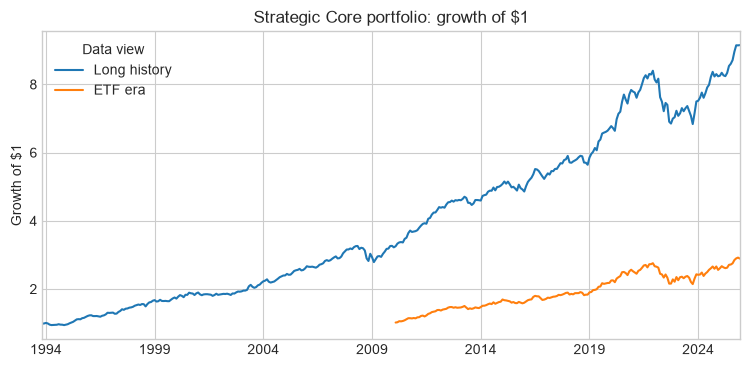

In [3]:
def wealth(r):
    return (1 + pd.Series(r, dtype=float)).cumprod()

def metrics(r, rf_series, benchmark=None):
    r = pd.Series(r, dtype=float).dropna()
    cash = pd.Series(rf_series, dtype=float).reindex(r.index)
    valid = pd.concat([r.rename('r'), cash.rename('rf')], axis=1).dropna()
    r, cash = valid['r'], valid['rf']
    nav = wealth(r)
    dd = nav / nav.cummax() - 1
    cagr = nav.iloc[-1] ** (12 / len(r)) - 1
    excess = r - cash
    sharpe = excess.mean() / excess.std(ddof=1) * np.sqrt(12)
    mdd = dd.min()
    ir = np.nan
    if benchmark is not None:
        active = r - pd.Series(benchmark, dtype=float).reindex(r.index)
        active_sd = active.std(ddof=1)
        if len(active.dropna()) > 1 and np.isfinite(active_sd) and not np.isclose(active_sd, 0.0):
            ir = active.mean() / active_sd * np.sqrt(12)
    calmar = np.nan if np.isclose(mdd, 0.0) else cagr / abs(mdd)
    return pd.Series({'CAGR': cagr, 'AnnVol': r.std(ddof=1) * np.sqrt(12), 'Sharpe': sharpe,
                      'MaxDD': mdd, 'Calmar': calmar, 'Information Ratio': ir})

core_metrics = pd.DataFrame({SAMPLE_SHORT[name]: metrics(p['Core'], p['RF']) for name, p in primary_panels.items()}).T
core_metrics.index.name = 'Data view'
display(core_metrics.drop(columns='Information Ratio').rename(columns={'AnnVol':'Annualized volatility','MaxDD':'Max drawdown'}).round(3))
fig, ax = plt.subplots(figsize=(9, 4))
for name, p in primary_panels.items(): wealth(p['Core']).plot(ax=ax, label=SAMPLE_SHORT[name])
ax.set(title='Strategic Core portfolio: growth of $1', ylabel='Growth of $1', xlabel=''); ax.legend(title='Data view'); plt.show()

## How much was evaluated?

The strategy-grid blocks produce **320 strategy-grid rows**: 96 rebalancing rows, 24 reserve rows, 72 drawdown-response rows, 56 rebound rows, 24 volatility rows, 6 broad-trend rows, and 42 occasional-use rows. Later post-selection displays add **12 separately accounted post-selection rows**: 6 borrowing-spread sensitivities and 6 latest-data update rows. Those 12 rows are checks on already selected outputs, not additional strategy searches. The 320 grid rows are correlated across parameters, data views, costs, and windows; they are not 320 independent hypothesis tests.

## Would more frequent or trigger-based rebalancing help?

The test compares letting weights drift, scheduled monthly/quarterly/annual resets, full resets after 2.5- to 10-point drift, and a smaller repair that moves only the most overweight and underweight sleeves. Costs are 0, 5, 10, and 25 basis points per unit of one-way turnover. The drift evidence below determines whether a reset has a target-allocation and risk-composition role; return rankings do not determine that governance choice.

,Data view,Maintenance rule,CAGR,Sharpe,Max drawdown,Total one-way turnover,Number of resets
0,Long history,Let weights drift,0.0788,0.6869,-0.2151,0.0000,0
1,Long history,Reset monthly,0.0712,0.7151,-0.1863,4.0946,386
2,Long history,Reset quarterly,0.0735,0.7478,-0.1839,2.7964,129
3,Long history,Reset annually,0.0741,0.7582,-0.1862,1.5260,33
4,ETF era,Let weights drift,0.0847,0.8182,-0.2402,0.0000,0
5,ETF era,Reset monthly,0.0689,0.7027,-0.2224,2.2275,191
6,ETF era,Reset quarterly,0.0711,0.7313,-0.2207,1.4775,64
7,ETF era,Reset annually,0.0693,0.7198,-0.2153,0.6980,16


,Data view,Terminal VTI weight,Terminal TLT weight,Terminal IEF weight,Terminal DBC weight,Terminal GLD weight,Maximum absolute drift from target,Sleeve at maximum drift,Month of maximum drift
0,Long history,0.7003,0.1581,0.0447,0.0195,0.0774,0.4038,VTI,2025-09-30
1,ETF era,0.6730,0.1639,0.0622,0.0240,0.0769,0.3750,VTI,2025-08-31


In etf era, no rebalancing ended with VTI at 67.30% versus its 30% target, and the largest observed absolute sleeve drift was 37.50%. The observed drift supports annual resetting only as target-allocation and risk-composition maintenance; it is not a performance winner. In the return comparison, drift produced 8.47% CAGR versus 6.93% for annual resets.

In long history, no rebalancing ended with VTI at 70.03% versus its 30% target, and the largest observed absolute sleeve drift was 40.38%. The observed drift supports annual resetting only as target-allocation and risk-composition maintenance; it is not a performance winner. In the return comparison, drift produced 7.88% CAGR versus 7.41% for annual resets.

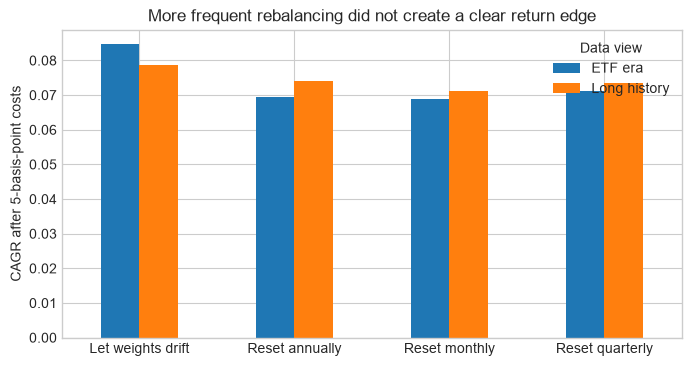

In [4]:
REBAL_RULES = [('passive', None), ('monthly', None), ('quarterly', None), ('annual', None)] + [
    (kind, threshold) for kind in ('full_threshold', 'pair_repair') for threshold in (.025, .05, .075, .10)]
REBAL_COSTS = (0, 5, 10, 25)

def scheduled(rule, date):
    m = date.month
    return rule == 'monthly' or (rule == 'quarterly' and m in (3, 6, 9, 12)) or (rule == 'annual' and m == 12)

def rebalance_path(panel, rule, threshold, bps, return_diagnostics=False):
    holdings = WEIGHTS.copy(); navs=[]; rets=[]; turns=[]; actions=0; prior_nav=1.0
    max_abs_drift=0.0; max_drift_sleeve=None; max_drift_month=None
    for date, row in panel.iterrows():
        holdings *= 1 + row[ASSETS]
        nav = holdings.sum(); pre = holdings / nav; maxdev = (pre - WEIGHTS).abs().max(); post = pre.copy(); act=False
        if maxdev > max_abs_drift:
            max_abs_drift=float(maxdev); max_drift_sleeve=(pre-WEIGHTS).abs().idxmax(); max_drift_month=date
        if scheduled(rule, date): act=True; post=WEIGHTS.copy()
        elif rule == 'full_threshold' and maxdev >= threshold: act=True; post=WEIGHTS.copy()
        elif rule == 'pair_repair' and maxdev >= threshold:
            over=(pre-WEIGHTS).idxmax(); under=(pre-WEIGHTS).idxmin(); amount=min(WEIGHTS[under]-pre[under], pre[over]-WEIGHTS[over])
            if amount > 0: post[over]-=amount; post[under]+=amount; act=True
        if act:
            turn=.5*(post-pre).abs().sum(); nav *= 1-turn*bps/10_000; holdings=post*nav; turns.append(turn); actions+=1
        rets.append(nav/prior_nav-1); navs.append(nav); prior_nav=nav
    result=(pd.Series(rets, index=panel.index), sum(turns), actions)
    if return_diagnostics:
        result += (holdings/holdings.sum(), max_abs_drift, max_drift_sleeve, max_drift_month)
    return result

rebalance_rows=[]
for dataset, panel in primary_panels.items():
    for rule, threshold in REBAL_RULES:
        for bps in REBAL_COSTS:
            r, turn, actions = rebalance_path(panel, rule, threshold, bps)
            s=metrics(r, panel['RF'], panel['Core'])
            rebalance_rows.append({'dataset':dataset,'rule':rule,'threshold':threshold,'cost_bps':bps,
                                   'turnover':turn,'actions':actions,**s.to_dict()})
rebalance_results=pd.DataFrame(rebalance_rows)
focus=rebalance_results.query("cost_bps == 5 and rule in ['passive','monthly','quarterly','annual']").copy()
focus['Sample']=focus['dataset'].map(SAMPLE_SHORT)
focus['Maintenance rule']=focus['rule'].map({'passive':'Let weights drift','monthly':'Reset monthly','quarterly':'Reset quarterly','annual':'Reset annually'})
focus_reader=focus[['Sample','Maintenance rule','CAGR','Sharpe','MaxDD','turnover','actions']].rename(columns={'Sample':'Data view','MaxDD':'Max drawdown','turnover':'Total one-way turnover','actions':'Number of resets'})
display(focus_reader.reset_index(drop=True).round(4))

drift_rows=[]
for dataset,panel in primary_panels.items():
    _r,_turn,_actions,terminal,max_abs_drift,max_drift_sleeve,max_drift_month=rebalance_path(
        panel,'passive',None,5,return_diagnostics=True)
    drift_rows.append({'dataset':dataset,'Data view':SAMPLE_SHORT[dataset],
                       **{f'Terminal {asset} weight':terminal[asset] for asset in ASSETS},
                       'Maximum absolute drift from target':max_abs_drift,
                       'Sleeve at maximum drift':max_drift_sleeve,
                       'Month of maximum drift':max_drift_month.date()})
drift_diagnostics=pd.DataFrame(drift_rows)
display(drift_diagnostics.drop(columns='dataset').round(4))
for dataset, group in focus.groupby('dataset'):
    drift = group[group['rule']=='passive'].iloc[0]; annual = group[group['rule']=='annual'].iloc[0]
    d=drift_diagnostics.set_index('dataset').loc[dataset]
    if d['Maximum absolute drift from target'] >= .05:
        maintenance_text="The observed drift supports annual resetting only as target-allocation and risk-composition maintenance; it is not a performance winner."
    else:
        maintenance_text="The observed drift does not by itself establish a need for annual resetting."
    display(Markdown(f"In {SAMPLE_SHORT[dataset].lower()}, no rebalancing ended with VTI at {d['Terminal VTI weight']:.2%} versus its 30% target, and the largest observed absolute sleeve drift was {d['Maximum absolute drift from target']:.2%}. {maintenance_text} In the return comparison, drift produced {drift['CAGR']:.2%} CAGR versus {annual['CAGR']:.2%} for annual resets."))
chart=focus.assign(rule_name=focus['Maintenance rule']).pivot(index='rule_name',columns='Sample',values='CAGR')
chart.plot(kind='bar',figsize=(8,4),title='More frequent rebalancing did not create a clear return edge'); plt.ylabel('CAGR after 5-basis-point costs'); plt.xlabel(''); plt.xticks(rotation=0); plt.legend(title='Data view'); plt.show()

## Would permanent dry powder improve the portfolio?

The portfolio begins with 0%, 5%, 10%, 15%, 20%, or 30% in cash. Cash compounds at the lagged Treasury-bill return while the invested sleeves are either reset annually or whenever a sleeve drifts five percentage points from target, with 5-basis-point trading costs. Because the cash is not replenished by a foresight-based trigger, this is a genuine standing reserve rather than an idealized “buy the dip” rule.

,Data view,Starting cash reserve,Maintenance,CAGR,Sharpe,Max drawdown,Information Ratio
0,Long history,0.00,Reset annually,0.0741,0.7582,-0.1862,0.3890
1,Long history,0.00,Reset after 5-point drift,0.0764,0.7876,-0.1793,0.8225
2,Long history,0.05,Reset annually,0.0727,0.7574,-0.1835,0.1863
3,Long history,0.05,Reset after 5-point drift,0.0751,0.7868,-0.1768,0.5782
4,Long history,0.10,Reset annually,0.0714,0.7563,-0.1806,-0.0151
5,Long history,0.10,Reset after 5-point drift,0.0737,0.7859,-0.1747,0.3068
6,Long history,0.15,Reset annually,0.0699,0.7550,-0.1773,-0.1816
7,Long history,0.15,Reset after 5-point drift,0.0722,0.7846,-0.1724,0.0740
8,Long history,0.20,Reset annually,0.0685,0.7533,-0.1738,-0.3065
9,Long history,0.20,Reset after 5-point drift,0.0707,0.7831,-0.1698,-0.1023


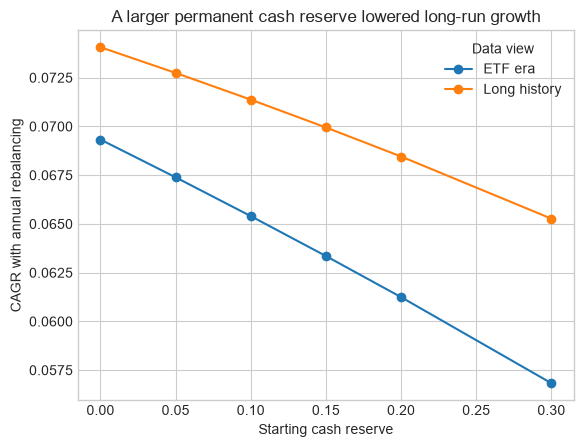

In [5]:
def reserve_path(panel, reserve, rule, threshold=.05, bps=5):
    core=WEIGHTS*(1-reserve); cash=float(reserve); prior=1.0; out=[]
    for date,row in panel.iterrows():
        cash *= 1+row['RF']; core *= 1+row[ASSETS]; core_nav=core.sum(); pre=core/core_nav; maxdev=(pre-WEIGHTS).abs().max(); act=False
        if scheduled(rule,date): act=True
        elif rule=='full_threshold' and maxdev>=threshold: act=True
        if act:
            turn=.5*(pre-WEIGHTS).abs().sum(); core_nav*=1-turn*bps/10_000; core=WEIGHTS*core_nav
        nav=core_nav+cash; out.append(nav/prior-1); prior=nav
    return pd.Series(out,index=panel.index)

reserve_rows=[]
for dataset,panel0 in panels.items():
    panel=panel0.loc[:'2025-12-31']
    for reserve in (0,.05,.10,.15,.20,.30):
        for rule,label in [('annual','annual'),('full_threshold','full threshold 5pp')]:
            r=reserve_path(panel,reserve,rule); s=metrics(r,panel['RF'],panel['Core'])
            reserve_rows.append({'dataset':dataset,'reserve':reserve,'maintenance':label,**s.to_dict()})
reserve_results=pd.DataFrame(reserve_rows)
reserve_reader=reserve_results.copy(); reserve_reader['Sample']=reserve_reader['dataset'].map(SAMPLE_SHORT)
reserve_reader['Maintenance']=reserve_reader['maintenance'].map({'annual':'Reset annually','full threshold 5pp':'Reset after 5-point drift'})
reserve_reader=reserve_reader[['Sample','reserve','Maintenance','CAGR','Sharpe','MaxDD','Information Ratio']].rename(columns={'Sample':'Data view','reserve':'Starting cash reserve','MaxDD':'Max drawdown'})
display(reserve_reader.round(4))
for dataset,g in reserve_results.query("maintenance == 'annual'").groupby('dataset'):
    plt.plot(g['reserve'],g['CAGR'],marker='o',label=SAMPLE_SHORT[dataset])
plt.title('A larger permanent cash reserve lowered long-run growth'); plt.xlabel('Starting cash reserve'); plt.ylabel('CAGR with annual rebalancing'); plt.legend(title='Data view'); plt.show()

## Should exposure change after a drawdown?

Two opposing ideas are tested after a 10%, 15%, or 20% portfolio decline. The **defensive version** cuts exposure to 0.50x or 0.75x; the **buy-the-dip version** raises it to 1.25x or 1.50x. Signals are observed at month-end and applied one month later. Each idea is tested while weights are allowed to drift, reset annually, or reset after a five-percentage-point drift.

CAGR advantage vs same-average exposure  Information Ratio
Data view    Exposure response                                                                        
ETF era      Add exposure after a drawdown                                   0.0014             0.1525
             Cut exposure after a drawdown                                  -0.0016            -0.1652
Long history Add exposure after a drawdown                                   0.0000             0.0232
             Cut exposure after a drawdown                                  -0.0001            -0.0347

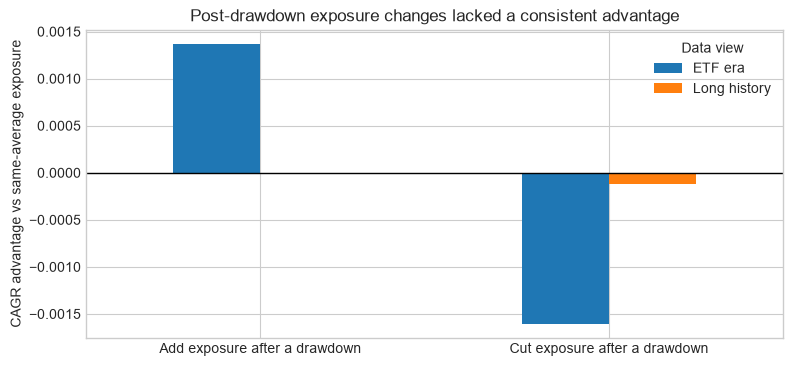

In [6]:
STATE_BASES=('PASSIVE','ANNUAL','FULL_5PP')
def base_core_path(panel,policy):
    holdings=WEIGHTS.copy(); prior=1.0; rets=[]; navs=[]
    for date,row in panel.iterrows():
        holdings*=1+row[ASSETS]; nav=holdings.sum(); w=holdings/nav
        reb=(policy=='ANNUAL' and date.month==12) or (policy=='FULL_5PP' and (w-WEIGHTS).abs().max()>=.05)
        if reb:
            turn=.5*(w-WEIGHTS).abs().sum(); nav*=1-turn*TC; holdings=WEIGHTS*nav
        rets.append(nav/prior-1); navs.append(nav); prior=nav
    return pd.Series(rets,index=panel.index),pd.Series(navs,index=panel.index)

def state_signal(family,params,core,nav):
    desired=pd.Series(1.0,index=core.index)
    if family.startswith('drawdown'):
        threshold,level=params; dd=nav/nav.cummax()-1; desired.loc[dd<=-threshold]=level
    elif family=='vol_risk_brake':
        window,level=params; vols=core.rolling(window).std(ddof=1)*np.sqrt(12); history=[]
        for i,v in enumerate(vols):
            if pd.isna(v): continue
            if len(history)>=24 and v>np.quantile(history,.75,method='linear'): desired.iloc[i]=level
            history.append(v)
    return desired

def economic(core,cash,exposure): return exposure*core-(exposure-1)*cash
def apply_state(core,cash,desired):
    applied=desired.shift(1).fillna(1.0); nav=1.0; navs=[]; rets=[]
    for i,(c,rfv,e) in enumerate(zip(core,cash,applied)):
        nav*=1+economic(c,rfv,e)
        if i<len(core)-1: nav*=1-abs(desired.iloc[i]-e)*TC
        navs.append(nav); rets.append(nav/(navs[i-1] if i else 1)-1)
    avg=applied.mean(); matched=economic(core,cash,avg)
    return pd.Series(rets,index=core.index),applied,matched

draw_rows=[]
for dataset,p0 in panels.items():
    p=p0.loc[:'2025-12-31']
    for policy in STATE_BASES:
        core,nav=base_core_path(p,policy)
        for threshold in (.10,.15,.20):
            for family,levels in [('Cut exposure after a drawdown',(.50,.75)),('Add exposure after a drawdown',(1.25,1.50))]:
                for level in levels:
                    desired=state_signal('drawdown', (threshold,level),core,nav); r,e,m=apply_state(core,p['RF'],desired); s=metrics(r,p['RF'],m)
                    draw_rows.append({'dataset':dataset,'base':policy,'family':family,'threshold':threshold,'exposure':level,
                                      'activation':(e!=1).mean(),'timing CAGR':s['CAGR']-metrics(m,p['RF'])['CAGR'],**s.to_dict()})
draw_results=pd.DataFrame(draw_rows)
draw_reader=draw_results.assign(Sample=draw_results['dataset'].map(SAMPLE_SHORT)).groupby(['Sample','family'])[['timing CAGR','Information Ratio']].median()
draw_reader=draw_reader.rename(columns={'timing CAGR':'CAGR advantage vs same-average exposure'})
draw_reader.index.names=['Data view','Exposure response']
display(draw_reader.round(4))
chart=draw_results.assign(Sample=draw_results['dataset'].map(SAMPLE_SHORT)).groupby(['Sample','family'])['timing CAGR'].median().unstack(0)
chart.plot(kind='bar',figsize=(9,4),title='Post-drawdown exposure changes lacked a consistent advantage'); plt.axhline(0,color='black',lw=1); plt.ylabel('CAGR advantage vs same-average exposure'); plt.xlabel(''); plt.xticks(rotation=0); plt.legend(title='Data view'); plt.show()

## Would waiting for a rebound improve the entry?

A 10% or 20% drawdown makes the rule eligible. After the portfolio rebounds 5% from its trough, exposure rises to 1.25x or 1.50x for three or six months. This “rebound confirmation” tries to avoid adding risk while prices are still falling. It uses a one-month implementation lag and the same 5-basis-point cost per unit of exposure change.

,Data view,Drawdown trigger,Exposure after rebound,Months held,Time active,Evaluation status,CAGR advantage vs same-average exposure,Sharpe,Max drawdown
0,Long history,0.1,1.25,3,0.0311,Triggered,-0.0003,0.7077,-0.1868
1,Long history,0.1,1.25,6,0.0466,Triggered,-0.0007,0.7030,-0.1879
2,Long history,0.1,1.50,3,0.0311,Triggered,-0.0006,0.6975,-0.1875
3,Long history,0.1,1.50,6,0.0466,Triggered,-0.0014,0.6881,-0.1895
4,Long history,0.2,1.25,3,0.0000,No trigger / not evaluable,0.0000,0.7161,-0.1862
5,Long history,0.2,1.25,6,0.0000,No trigger / not evaluable,0.0000,0.7161,-0.1862
6,Long history,0.2,1.50,3,0.0000,No trigger / not evaluable,0.0000,0.7161,-0.1862
7,Long history,0.2,1.50,6,0.0000,No trigger / not evaluable,0.0000,0.7161,-0.1862
32,ETF era,0.1,1.25,3,0.0628,Triggered,-0.0028,0.6552,-0.2507
33,ETF era,0.1,1.25,6,0.0942,Triggered,-0.0010,0.6773,-0.2251


**No-trigger configurations:** 28 rows across full and shorter windows. They are marked not evaluable and excluded from the median effect summary; they are not counted as failed evidence.

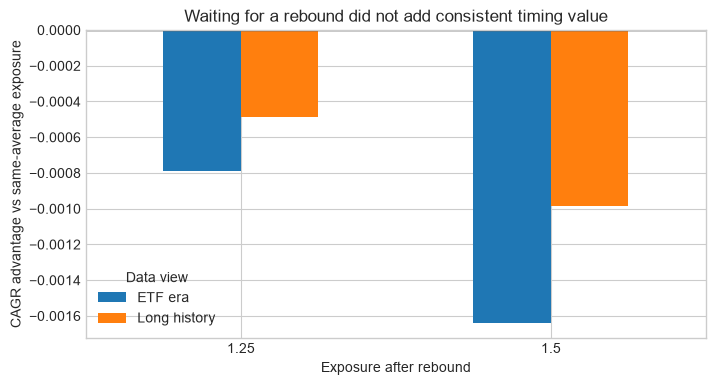

In [7]:
def rebound_signal(core,dd_threshold,on,hold,rebound=.05):
    nav=wealth(core); dd=nav/nav.cummax()-1; signal=pd.Series(1.0,index=core.index); armed=False; trough=np.nan; remaining=0
    for i in range(len(core)):
        if remaining>0: signal.iloc[i]=on; remaining-=1; continue
        if not armed and dd.iloc[i]<=-dd_threshold: armed=True; trough=nav.iloc[i]
        if armed:
            trough=min(trough,nav.iloc[i])
            if nav.iloc[i]/trough-1>=rebound: remaining=hold; armed=False; signal.iloc[i]=on; remaining-=1
    return signal

def lagged_overlay(core,cash,signal):
    exposure=signal.shift(1).fillna(1.0); previous=1.0; values=[]
    for c,rfv,e in zip(core,cash,exposure):
        values.append(economic(c,rfv,e)-abs(e-previous)*TC); previous=e
    r=pd.Series(values,index=core.index); avg=exposure.mean(); matched=economic(core,cash,avg)
    return r,exposure,matched

rebound_rows=[]
rebound_periods={'long_history':[('FULL',None,None),('1993–2004','1993-11-30','2004-12-31'),('2005–2014','2005-01-31','2014-12-31'),('2015–2025','2015-01-31','2025-12-31')],
                 'etf_era':[('FULL',None,'2025-12-31'),('2010–2017','2010-02-28','2017-12-31'),('2018–2025','2018-01-31','2025-12-31')]}
for dataset,periods in rebound_periods.items():
    for label,start,end in periods:
        p=panels[dataset].loc[start:end]
        for threshold in (.10,.20):
            for on in (1.25,1.50):
                for hold in (3,6):
                    sig=rebound_signal(p['Core'],threshold,on,hold); r,e,m=lagged_overlay(p['Core'],p['RF'],sig); s=metrics(r,p['RF'],m)
                    rebound_rows.append({'dataset':dataset,'period':label,'threshold':threshold,'on':on,'hold':hold,
                                         'activation':(e>1).mean(),'timing CAGR':s['CAGR']-metrics(m,p['RF'])['CAGR'],**s.to_dict()})
rebound_results=pd.DataFrame(rebound_rows)
rebound_results['Evaluation status']=np.where(rebound_results['activation']>0,'Triggered','No trigger / not evaluable')
rebound_reader=rebound_results.query("period == 'FULL'").copy(); rebound_reader['Sample']=rebound_reader['dataset'].map(SAMPLE_SHORT)
rebound_reader=rebound_reader[['Sample','threshold','on','hold','activation','Evaluation status','timing CAGR','Sharpe','MaxDD']].rename(columns={'Sample':'Data view','threshold':'Drawdown trigger','on':'Exposure after rebound','hold':'Months held','activation':'Time active','timing CAGR':'CAGR advantage vs same-average exposure','MaxDD':'Max drawdown'})
display(rebound_reader.round(4))
no_trigger_count=int((rebound_results['Evaluation status']=='No trigger / not evaluable').sum())
display(Markdown(f"**No-trigger configurations:** {no_trigger_count} rows across full and shorter windows. They are marked not evaluable and excluded from the median effect summary; they are not counted as failed evidence."))
rebound_evaluable=rebound_results.query("period == 'FULL' and activation > 0").copy()
chart=rebound_evaluable.assign(Sample=lambda x:x['dataset'].map(SAMPLE_SHORT)).groupby(['Sample','on'])['timing CAGR'].median().unstack(0)
chart.plot(kind='bar',figsize=(8,4),title='Waiting for a rebound did not add consistent timing value'); plt.axhline(0,color='black',lw=1); plt.ylabel('CAGR advantage vs same-average exposure'); plt.xlabel('Exposure after rebound'); plt.xticks(rotation=0); plt.legend(title='Data view'); plt.show()

## Should the portfolio de-risk when volatility spikes?

Six- and twelve-month realized volatility are compared with the 75th percentile of earlier observations, using standard linear interpolation. The rule waits for 24 valid volatility estimates before making any decision, then cuts exposure to 0.50x or 0.75x one month after an unusually high reading.

,Data view,Weight maintenance,Volatility window (months),Exposure after high volatility,Time active,CAGR advantage vs same-average exposure,Sharpe,Max drawdown
0,Long history,Let weights drift,6,0.50,0.3161,-0.0051,0.6565,-0.1516
1,Long history,Let weights drift,6,0.75,0.3161,-0.0025,0.6829,-0.1727
2,Long history,Let weights drift,12,0.50,0.3264,-0.0034,0.6901,-0.1516
3,Long history,Let weights drift,12,0.75,0.3264,-0.0016,0.6980,-0.1727
4,Long history,Reset annually,6,0.50,0.2513,-0.0018,0.7577,-0.1131
5,Long history,Reset annually,6,0.75,0.2513,-0.0009,0.7668,-0.1489
6,Long history,Reset annually,12,0.50,0.2902,-0.0014,0.7463,-0.1315
7,Long history,Reset annually,12,0.75,0.2902,-0.0007,0.7614,-0.1578
8,Long history,Reset after 5-point drift,6,0.50,0.2461,-0.0018,0.7867,-0.1218
9,Long history,Reset after 5-point drift,6,0.75,0.2461,-0.0009,0.7962,-0.1423


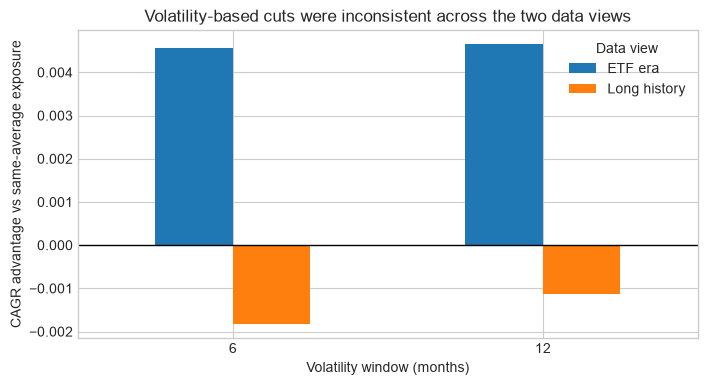

In [8]:
vol_rows=[]
for dataset,p0 in panels.items():
    p=p0.loc[:'2025-12-31']
    for policy in STATE_BASES:
        core,nav=base_core_path(p,policy)
        for window in (6,12):
            for level in (.50,.75):
                desired=state_signal('vol_risk_brake',(window,level),core,nav); r,e,m=apply_state(core,p['RF'],desired); s=metrics(r,p['RF'],m)
                vol_rows.append({'dataset':dataset,'base':policy,'window':window,'exposure':level,'activation':(e!=1).mean(),
                                 'timing CAGR':s['CAGR']-metrics(m,p['RF'])['CAGR'],**s.to_dict()})
vol_results=pd.DataFrame(vol_rows)
vol_reader=vol_results.copy(); vol_reader['Sample']=vol_reader['dataset'].map(SAMPLE_SHORT); vol_reader['Weight maintenance']=vol_reader['base'].map(BASE_LABELS)
vol_reader=vol_reader[['Sample','Weight maintenance','window','exposure','activation','timing CAGR','Sharpe','MaxDD']].rename(columns={'Sample':'Data view','window':'Volatility window (months)','exposure':'Exposure after high volatility','activation':'Time active','timing CAGR':'CAGR advantage vs same-average exposure','MaxDD':'Max drawdown'})
display(vol_reader.round(4))
chart=vol_results.assign(Sample=vol_results['dataset'].map(SAMPLE_SHORT)).groupby(['Sample','window'])['timing CAGR'].median().unstack(0)
chart.plot(kind='bar',figsize=(8,4),title='Volatility-based cuts were inconsistent across the two data views'); plt.axhline(0,color='black',lw=1); plt.ylabel('CAGR advantage vs same-average exposure'); plt.xlabel('Volatility window (months)'); plt.xticks(rotation=0); plt.legend(title='Data view'); plt.show()

## The trend rule that stood out

The trend score is Core's compounded six-month return. A positive score at month *t* sets exposure for month *t+1*. The normal state is 1x; the leveraged state is 1.25x, 1.50x, or 2x. Cash-financed return is `exposure × Core − (exposure − 1) × Treasury-bill return`, less 5 basis points per unit change in exposure.

To separate timing skill from simply carrying more leverage, each dynamic rule is compared with a portfolio held constantly at the rule's own average exposure. This **same-average-exposure comparison** uses identical cash financing but has no recurring timing turnover.

Under this linear financing formula, constant leverage simply scales excess returns, so its Sharpe ratio is algebraically unchanged. The trend rule uses the same binary timing signal at every leveraged-state size; exposure changes and trading costs scale proportionally, so active-return Information Ratio is also identical across 1.25x, 1.5x, and 2x **by construction**. Repeated values are therefore not independent evidence.

The stronger trend attribution below comes from **Long history**, so it relies more on the proxy view. Its Treasury proxy returns use a modeled duration/convexity construction, and this compact notebook cannot independently reconstruct every upstream splice. That limits how much policy weight the stronger result can carry; detailed provenance remains in the appendix.

,Data view,Leveraged-state exposure,Time in leveraged state,Average exposure,CAGR,Sharpe,Max drawdown,Same-average-exposure CAGR
0,Long history,1.25,0.7902,1.1975,0.0827,0.7716,-0.2006,0.0800
1,Long history,1.50,0.7902,1.3951,0.0941,0.8079,-0.2148,0.0886
2,Long history,2.00,0.7902,1.7902,0.1166,0.8494,-0.2429,0.1055
3,ETF era,1.25,0.7173,1.1793,0.0796,0.7343,-0.2464,0.0783
4,ETF era,1.50,0.7173,1.3586,0.0902,0.7519,-0.2700,0.0876
5,ETF era,2.00,0.7173,1.7173,0.1108,0.7675,-0.3160,0.1056


,Data view,Active-return Information Ratio (same at every size by construction),Primary-window months,Simple IID-style t diagnostic
0,ETF era,0.0931,191,0.3715
1,Long history,0.2756,386,1.5632


**Compact uncertainty diagnostic.** Using primary-window months, `t = active-return IR × sqrt(n/12)`. This is a simple IID-style scale diagnostic only—not inference adjusted for signal selection or serial dependence—and it does not create p-value-driven decision logic.

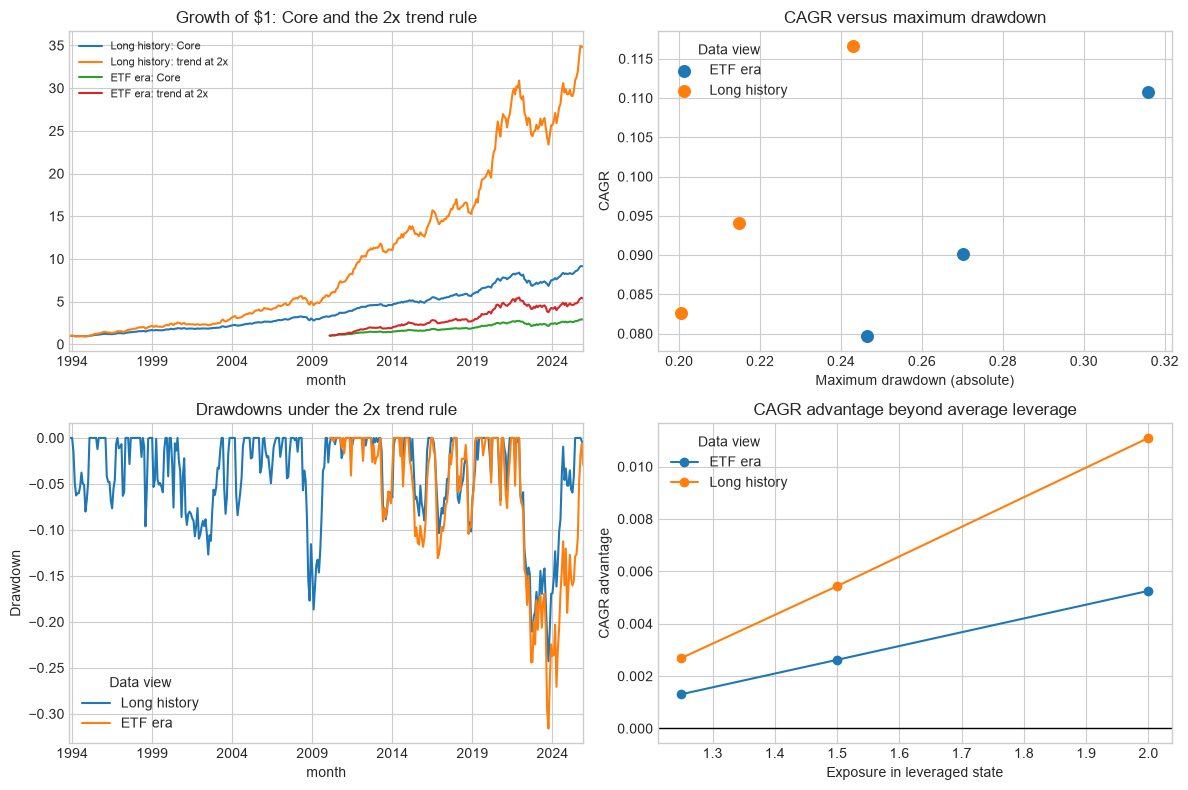

**Long history, 2x leveraged state:** CAGR 11.66% versus 10.55% for constant average leverage; Sharpe 0.85 versus 0.72; maximum drawdown -24.29%; active-return Information Ratio 0.28.

**ETF era, 2x leveraged state:** CAGR 11.08% versus 10.56% for constant average leverage; Sharpe 0.77 versus 0.70; maximum drawdown -31.60%; active-return Information Ratio 0.09.

### Latest-data update sensitivity

,Window,Strategy,Months,CAGR,Sharpe,Max drawdown
0,Primary comparison through 2025-12,Core at 1x,191,0.0690,0.7035,-0.2223
1,Primary comparison through 2025-12,Annual weight reset,191,0.0693,0.7198,-0.2153
2,Primary comparison through 2025-12,"Broad trend, 2x state",191,0.1108,0.7675,-0.3160
3,Latest-data update through 2026-07,Core at 1x,198,0.0687,0.6905,-0.2223
4,Latest-data update through 2026-07,Annual weight reset,198,0.0690,0.7049,-0.2153
5,Latest-data update through 2026-07,"Broad trend, 2x state",198,0.1097,0.7484,-0.3160


January–July 2026 is shown only as an update sensitivity for Core, annual maintenance, and the broad trend rule. It is not used to give the trend family extra months in the primary cross-family comparison.

In [9]:
def six_month_score(core): return (1+core).rolling(6).apply(np.prod,raw=True)-1
def trend_path(panel,on):
    score=six_month_score(panel['Core']); state=pd.Series(1.0,index=panel.index); state.loc[score>0]=on
    exposure=state.shift(1).fillna(1.0); cost=exposure.diff().abs().fillna((exposure.iloc[0]-1).__abs__())*TC
    dynamic=economic(panel['Core'],panel['RF'],exposure)-cost; avg=exposure.mean(); matched=economic(panel['Core'],panel['RF'],avg)
    return score,state,exposure,dynamic,matched

trend_rows=[]; trend_paths={}
for dataset,p in primary_panels.items():
    for on in (1.25,1.50,2.0):
        score,state,e,r,m=trend_path(p,on); sm=metrics(r,p['RF'],m); mm=metrics(m,p['RF']); bm=metrics(p['Core'],p['RF'])
        trend_paths[(dataset,on)]=(e,r,m)
        trend_rows.append({'dataset':dataset,'Sample':SAMPLE_SHORT[dataset],'Leveraged-state exposure':on,'Time in leveraged state':(e>1).mean(),'Average exposure':e.mean(),
                           'CAGR':sm['CAGR'],'Sharpe':sm['Sharpe'],'Calmar':sm['Calmar'],'Max drawdown':sm['MaxDD'],
                           'Same-average-exposure CAGR':mm['CAGR'],'Same-average-exposure Sharpe':mm['Sharpe'],'Same-average-exposure Calmar':mm['Calmar'],
                           'Information Ratio vs same-average exposure':sm['Information Ratio'],'Core CAGR':bm['CAGR']})
trend_results=pd.DataFrame(trend_rows)
trend_tradeoff=trend_results[['Sample','Leveraged-state exposure','Time in leveraged state','Average exposure','CAGR','Sharpe','Max drawdown','Same-average-exposure CAGR']]
display(trend_tradeoff.rename(columns={'Sample':'Data view'}).round(4))
trend_attribution=trend_results.groupby(['dataset','Sample'],as_index=False).first()[['dataset','Sample','Information Ratio vs same-average exposure']]
trend_attribution['Primary-window months']=trend_attribution['dataset'].map({name:len(p) for name,p in primary_panels.items()})
trend_attribution['Simple IID-style t diagnostic']=trend_attribution['Information Ratio vs same-average exposure']*np.sqrt(trend_attribution['Primary-window months']/12)
trend_attribution=trend_attribution.rename(columns={'Information Ratio vs same-average exposure':'Active-return Information Ratio (same at every size by construction)'})
trend_attribution=trend_attribution.drop(columns='dataset')
display(trend_attribution.rename(columns={'Sample':'Data view'}).round(4))
display(Markdown('**Compact uncertainty diagnostic.** Using primary-window months, `t = active-return IR × sqrt(n/12)`. This is a simple IID-style scale diagnostic only—not inference adjusted for signal selection or serial dependence—and it does not create p-value-driven decision logic.'))

fig,axes=plt.subplots(2,2,figsize=(12,8))
for dataset,p in primary_panels.items():
    e,r,m=trend_paths[(dataset,2.0)]; wealth(p['Core']).plot(ax=axes[0,0],label=f'{SAMPLE_SHORT[dataset]}: Core'); wealth(r).plot(ax=axes[0,0],label=f'{SAMPLE_SHORT[dataset]}: trend at 2x')
    (wealth(r)/wealth(r).cummax()-1).plot(ax=axes[1,0],label=SAMPLE_SHORT[dataset])
for dataset,g in trend_results.groupby('dataset'):
    axes[0,1].scatter(g['Max drawdown'].abs(),g['CAGR'],s=70,label=SAMPLE_SHORT[dataset])
    axes[1,1].plot(g['Leveraged-state exposure'],g['CAGR']-g['Same-average-exposure CAGR'],marker='o',label=SAMPLE_SHORT[dataset])
axes[0,0].set_title('Growth of $1: Core and the 2x trend rule'); axes[0,0].legend(fontsize=8)
axes[1,0].set_title('Drawdowns under the 2x trend rule'); axes[1,0].legend(title='Data view'); axes[1,0].set_ylabel('Drawdown')
axes[0,1].set_title('CAGR versus maximum drawdown'); axes[0,1].set_xlabel('Maximum drawdown (absolute)'); axes[0,1].set_ylabel('CAGR'); axes[0,1].legend(title='Data view')
axes[1,1].set_title('CAGR advantage beyond average leverage'); axes[1,1].set_xlabel('Exposure in leveraged state'); axes[1,1].set_ylabel('CAGR advantage'); axes[1,1].axhline(0,color='black',lw=1); axes[1,1].legend(title='Data view'); plt.tight_layout(); plt.show()

for _,row in trend_results.query("`Leveraged-state exposure` == 2.0").iterrows():
    display(Markdown(f"**{row['Sample']}, 2x leveraged state:** CAGR {row['CAGR']:.2%} versus {row['Same-average-exposure CAGR']:.2%} for constant average leverage; Sharpe {row['Sharpe']:.2f} versus {row['Same-average-exposure Sharpe']:.2f}; maximum drawdown {row['Max drawdown']:.2%}; active-return Information Ratio {row['Information Ratio vs same-average exposure']:.2f}."))

update_rows=[]
for window_label,p in [('Primary comparison through 2025-12',primary_panels['etf_era']),('Latest-data update through 2026-07',panels['etf_era'])]:
    annual_r,_,_=rebalance_path(p,'annual',None,5)
    _score,_state,_exposure,trend_r,_matched=trend_path(p,2.0)
    for strategy,r in [('Core at 1x',p['Core']),('Annual weight reset',annual_r),('Broad trend, 2x state',trend_r)]:
        s=metrics(r,p['RF'])
        update_rows.append({'Window':window_label,'Strategy':strategy,'Months':len(p),'CAGR':s['CAGR'],'Sharpe':s['Sharpe'],'Max drawdown':s['MaxDD']})
update_results=pd.DataFrame(update_rows)
display(Markdown('### Latest-data update sensitivity'))
display(update_results.round(4))
display(Markdown('January–July 2026 is shown only as an update sensitivity for Core, annual maintenance, and the broad trend rule. It is not used to give the trend family extra months in the primary cross-family comparison.'))

### How often was the rule actually leveraged?

In [10]:
activity=trend_results[['Sample','Leveraged-state exposure','Time in leveraged state','Average exposure']]
display(activity.rename(columns={'Sample':'Data view'}).round(4))
for _,row in trend_results.query("`Leveraged-state exposure` == 2.0").iterrows():
    display(Markdown(f"In the {row['Sample'].lower()} sample, the 2x state applied in {row['Time in leveraged state']:.1%} of months and average exposure was {row['Average exposure']:.2f}x. This is mostly a leveraged portfolio with periodic returns to 1x—not an occasional tactical boost."))

,Data view,Leveraged-state exposure,Time in leveraged state,Average exposure
0,Long history,1.25,0.7902,1.1975
1,Long history,1.50,0.7902,1.3951
2,Long history,2.00,0.7902,1.7902
3,ETF era,1.25,0.7173,1.1793
4,ETF era,1.50,0.7173,1.3586
5,ETF era,2.00,0.7173,1.7173


In the long history sample, the 2x state applied in 79.0% of months and average exposure was 1.79x. This is mostly a leveraged portfolio with periodic returns to 1x—not an occasional tactical boost.

In the etf era sample, the 2x state applied in 71.7% of months and average exposure was 1.72x. This is mostly a leveraged portfolio with periodic returns to 1x—not an occasional tactical boost.

### What if borrowing costs exceed Treasury bills?

The base formula finances leverage at the lagged Treasury-bill rate. The table below applies an additional constant annual borrowing spread of 0%, 1%, or 2% to the 2x trend rule and to its same-average-exposure comparator. This is a compact sensitivity—not a claim about any specific leveraged product.

In [11]:
spread_rows=[]
for dataset,p in primary_panels.items():
    exposure,dynamic,matched=trend_paths[(dataset,2.0)]
    for annual_spread in (0.00,0.01,0.02):
        monthly_spread=annual_spread/12
        dynamic_after_spread=dynamic-(exposure-1)*monthly_spread
        matched_after_spread=matched-(exposure.mean()-1)*monthly_spread
        dm=metrics(dynamic_after_spread,p['RF'],matched_after_spread)
        mm=metrics(matched_after_spread,p['RF'])
        spread_rows.append({'Data view':SAMPLE_SHORT[dataset],'Annual borrowing spread over Treasury bills':annual_spread,
                            'Dynamic CAGR':dm['CAGR'],'Dynamic Sharpe':dm['Sharpe'],
                            'Same-average-exposure CAGR':mm['CAGR'],
                            'CAGR advantage vs same-average exposure':dm['CAGR']-mm['CAGR']})
financing_sensitivity=pd.DataFrame(spread_rows)
display(financing_sensitivity.round(4))

def break_even_spread(panel, exposure, dynamic, core_sharpe):
    def gap(annual_spread):
        adjusted=dynamic-(exposure-1)*(annual_spread/12)
        return float(metrics(adjusted,panel['RF'])['Sharpe']-core_sharpe)
    lo,hi=0.0,0.02
    gap_lo,gap_hi=gap(lo),gap(hi)
    while gap_lo*gap_hi>0 and hi<1.0:
        hi*=2
        gap_hi=gap(hi)
    if gap_lo*gap_hi>0:
        return np.nan
    for _ in range(80):
        mid=(lo+hi)/2
        gap_mid=gap(mid)
        if gap_lo*gap_mid<=0:
            hi=mid; gap_hi=gap_mid
        else:
            lo=mid; gap_lo=gap_mid
    return (lo+hi)/2

tolerance_rows=[]
for dataset,p in primary_panels.items():
    data_view=SAMPLE_SHORT[dataset]
    core_sharpe=float(core_metrics.loc[data_view,'Sharpe'])
    exposure,dynamic,_matched=trend_paths[(dataset,2.0)]
    boundary=break_even_spread(p,exposure,dynamic,core_sharpe)
    tolerance_rows.append({'Data view':data_view,'1x Core Sharpe':core_sharpe,
                           'Approx. annual modeled spread where 2x trend Sharpe equals 1x Core Sharpe':boundary})
spread_tolerance=pd.DataFrame(tolerance_rows)
display(spread_tolerance.round(4))
boundary_text='; '.join(f"{row['Data view']}: {row['Approx. annual modeled spread where 2x trend Sharpe equals 1x Core Sharpe']:.2%}" for _,row in spread_tolerance.iterrows())
display(Markdown(f"Bracketed bisection using the actual recomputed Sharpe metrics gives these boundaries: {boundary_text}. Each is a **simplified model tolerance boundary only** under the notebook's constant-spread financing formula, not a product-cost estimate or product-fee inference."))

,Data view,Annual borrowing spread over Treasury bills,Dynamic CAGR,Dynamic Sharpe,Same-average-exposure CAGR,CAGR advantage vs same-average exposure
0,Long history,0.00,0.1166,0.8494,0.1055,0.0111
1,Long history,0.01,0.1079,0.7770,0.0969,0.0110
2,Long history,0.02,0.0993,0.7043,0.0883,0.0110
3,ETF era,0.00,0.1108,0.7675,0.1056,0.0053
4,ETF era,0.01,0.1030,0.7129,0.0977,0.0052
5,ETF era,0.02,0.0951,0.6581,0.0899,0.0052


,Data view,1x Core Sharpe,Approx. annual modeled spread where 2x trend Sharpe equals 1x Core Sharpe
0,Long history,0.7161,0.0184
1,ETF era,0.7035,0.0117


Bracketed bisection using the actual recomputed Sharpe metrics gives these boundaries: Long history: 1.84%; ETF era: 1.17%. Each is a **simplified model tolerance boundary only** under the notebook's constant-spread financing formula, not a product-cost estimate or product-fee inference.

## Occasional-use redesign: stricter signals, weaker robustness

The original trend rule was leveraged most of the time, so the next test redesigns it for **occasional use**. In each fresh sample, the six-month score must exceed the 70th, 80th, or 90th percentile of exactly the prior 36 valid scores. Exposure is otherwise 1x and rises to 1.5x or 2x one month after a qualifying score. Costs remain 5 basis points per unit of exposure change.

Every shorter evaluation window is rebuilt from scratch, including its own six-month score history and 36-score warm-up. A configuration passes the **consistency screen** only if its CAGR advantage over constant average leverage is positive in both full-data constructions and non-negative in every shorter window. This 0/6 screen carries the decisive adoption weight.

,Data view,Evaluation window,Required prior-score percentile,Leveraged-state exposure,Time in leveraged state,Average exposure,Rule CAGR,Same-average-exposure CAGR,Core CAGR,CAGR contribution from average leverage,CAGR advantage vs same-average exposure,Information Ratio vs same-average exposure
0,Long history,Full sample,0.7,1.5,0.2513,1.1256,0.0786,0.0768,0.0713,0.0056,0.0018,0.1224
1,Long history,Full sample,0.7,2.0,0.2513,1.2513,0.0858,0.0824,0.0713,0.0111,0.0035,0.1224
2,Long history,Full sample,0.8,1.5,0.1891,1.0946,0.0758,0.0754,0.0713,0.0042,0.0003,0.0205
3,Long history,Full sample,0.8,2.0,0.1891,1.1891,0.0801,0.0796,0.0713,0.0084,0.0005,0.0205
4,Long history,Full sample,0.9,1.5,0.1114,1.0557,0.0709,0.0737,0.0713,0.0025,-0.0029,-0.2957
5,Long history,Full sample,0.9,2.0,0.1114,1.1114,0.0704,0.0762,0.0713,0.0049,-0.0058,-0.2957
6,Long history,1993–2004,0.7,1.5,0.1642,1.0821,0.0860,0.0846,0.0813,0.0033,0.0015,0.1199
7,Long history,1993–2004,0.7,2.0,0.1642,1.1642,0.0906,0.0878,0.0813,0.0065,0.0028,0.1199
8,Long history,1993–2004,0.8,1.5,0.1418,1.0709,0.0840,0.0841,0.0813,0.0028,-0.0001,-0.0151
9,Long history,1993–2004,0.8,2.0,0.1418,1.1418,0.0866,0.0869,0.0813,0.0056,-0.0004,-0.0151


,Required prior-score percentile,Leveraged-state exposure,Long-history full view positive,ETF-era full view positive,All shorter windows non-negative,Passes consistency screen
0,0.7,1.5,True,False,False,False
1,0.7,2.0,True,False,False,False
2,0.8,1.5,True,False,False,False
3,0.8,2.0,True,False,False,False
4,0.9,1.5,False,False,False,False
5,0.9,2.0,False,False,False,False


**Configurations passing the consistency screen: 0 of 6.** Passing requires a positive CAGR advantage over constant average leverage in both full-data constructions and a non-negative advantage in every rebuilt shorter window. This is the decisive policy screen.

**All 6 of 6 occasional-use candidates are already negative in the full ETF-era primary window** versus their same-average-exposure comparators. The 0-of-6 conclusion is therefore not driven solely by the shorter-window consistency requirements.

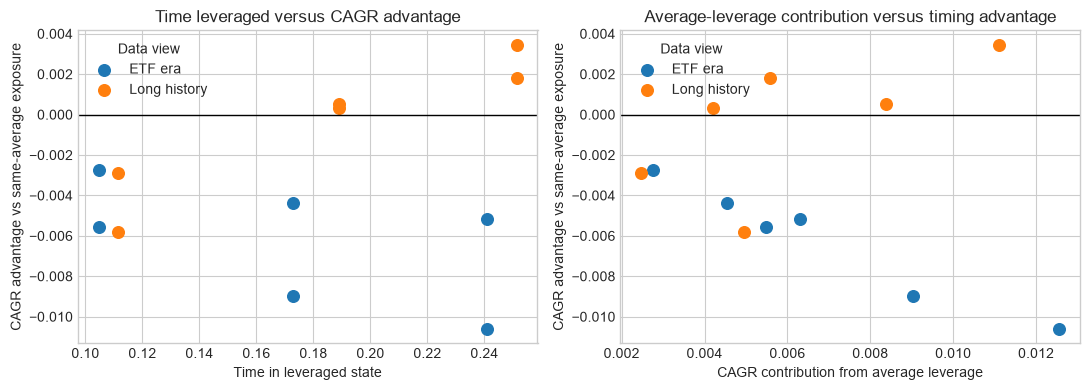

In [12]:
SPARSE_PERIODS={'long_history':[('FULL',None,None),('1993–2004','1993-11-30','2004-12-31'),('2005–2014','2005-01-31','2014-12-31'),('2015–2025','2015-01-31','2025-12-31')],
                'etf_era':[('FULL',None,'2025-12-31'),('2010–2017','2010-02-28','2017-12-31'),('2018–2025','2018-01-31','2025-12-31')]}
def sparse_path(panel,q,on):
    score=six_month_score(panel['Core']); desired=pd.Series(1.0,index=panel.index); valid=[]
    for i,value in enumerate(score):
        if pd.notna(value) and len(valid)>=36 and value>np.quantile(valid[-36:],q,method='linear'): desired.iloc[i]=on
        if pd.notna(value): valid.append(value)
    exposure=desired.shift(1).fillna(1.0); cost=exposure.diff().abs().fillna(0)*TC
    dynamic=economic(panel['Core'],panel['RF'],exposure)-cost; avg=exposure.mean(); matched=economic(panel['Core'],panel['RF'],avg)
    return exposure,dynamic,matched

sparse_rows=[]
for dataset,periods in SPARSE_PERIODS.items():
    for period,start,end in periods:
        p=panels[dataset].loc[start:end]
        for q in (.70,.80,.90):
            for on in (1.5,2.0):
                e,r,m=sparse_path(p,q,on); dm=metrics(r,p['RF'],m); mm=metrics(m,p['RF']); bm=metrics(p['Core'],p['RF'])
                sparse_rows.append({'dataset':dataset,'period':period,'q':q,'ON':on,'activation':(e>1).mean(),'average exposure':e.mean(),
                                    'dynamic CAGR':dm['CAGR'],'matched CAGR':mm['CAGR'],'Core CAGR':bm['CAGR'],
                                    'exposure contribution':mm['CAGR']-bm['CAGR'],'timing CAGR':dm['CAGR']-mm['CAGR'],'active IR':dm['Information Ratio']})
sparse_results=pd.DataFrame(sparse_rows)
sparse_reader=sparse_results.copy(); sparse_reader['Sample']=sparse_reader['dataset'].map(SAMPLE_SHORT); sparse_reader['period']=sparse_reader['period'].replace({'FULL':'Full sample'})
sparse_reader=sparse_reader[['Sample','period','q','ON','activation','average exposure','dynamic CAGR','matched CAGR','Core CAGR','exposure contribution','timing CAGR','active IR']].rename(columns={
    'period':'Evaluation window','q':'Required prior-score percentile','ON':'Leveraged-state exposure','activation':'Time in leveraged state',
    'average exposure':'Average exposure','dynamic CAGR':'Rule CAGR','matched CAGR':'Same-average-exposure CAGR',
    'exposure contribution':'CAGR contribution from average leverage','timing CAGR':'CAGR advantage vs same-average exposure',
    'active IR':'Information Ratio vs same-average exposure'})
display(sparse_reader.rename(columns={'Sample':'Data view'}).round(4))

configs=sparse_results[['q','ON']].drop_duplicates()
survivor=[]
for _,cfg in configs.iterrows():
    g=sparse_results[(sparse_results.q==cfg.q)&(sparse_results.ON==cfg.ON)]
    full=g[g.period=='FULL'].set_index('dataset')['timing CAGR']
    subs=g[g.period!='FULL']['timing CAGR']
    survivor.append({'Required prior-score percentile':cfg.q,'Leveraged-state exposure':cfg.ON,
                     'Long-history full view positive':full['long_history']>0,'ETF-era full view positive':full['etf_era']>0,
                     'All shorter windows non-negative':(subs>=0).all(),'Passes consistency screen':(full>0).all() and (subs>=0).all()})
adoption=pd.DataFrame(survivor); survivors=int(adoption['Passes consistency screen'].sum())
display(adoption)
display(Markdown(f"**Configurations passing the consistency screen: {survivors} of {len(adoption)}.** Passing requires a positive CAGR advantage over constant average leverage in both full-data constructions and a non-negative advantage in every rebuilt shorter window. This is the decisive policy screen."))
full=sparse_results.query("period == 'FULL'")
etf_full=full.query("dataset == 'etf_era'")
etf_full_negative=int((etf_full['timing CAGR']<0).sum())
display(Markdown(f"**All {etf_full_negative} of {len(etf_full)} occasional-use candidates are already negative in the full ETF-era primary window** versus their same-average-exposure comparators. The 0-of-6 conclusion is therefore not driven solely by the shorter-window consistency requirements."))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for dataset,g in full.groupby('dataset'):
    axes[0].scatter(g['activation'],g['timing CAGR'],label=SAMPLE_SHORT[dataset],s=70); axes[1].scatter(g['exposure contribution'],g['timing CAGR'],label=SAMPLE_SHORT[dataset],s=70)
axes[0].axhline(0,color='black',lw=1); axes[0].set(title='Time leveraged versus CAGR advantage',xlabel='Time in leveraged state',ylabel='CAGR advantage vs same-average exposure')
axes[1].axhline(0,color='black',lw=1); axes[1].set(title='Average-leverage contribution versus timing advantage',xlabel='CAGR contribution from average leverage',ylabel='CAGR advantage vs same-average exposure')
axes[0].legend(title='Data view'); axes[1].legend(title='Data view'); plt.tight_layout(); plt.show()

## Practical implementation remains unproven

The historical calculation assumes clean cash financing. The mapping below is only a qualitative check on whether a public leveraged product resembles each sleeve. A historical proxy is not proof that live financing, tracking, liquidity, taxes, and product continuity will behave like the formula.

In [13]:
implementation_map=pd.DataFrame([
    ('VTI','SSO','Broad-equity leverage proxy, not an exact VTI implementation.'),
    ('TLT','UBT','Closest historical proxy among the products checked.'),
    ('IEF','UST','Closest historical proxy among the products checked.'),
    ('GLD','Historical UGL data','Historical proxy only; the product path still matters.'),
    ('DBC','No sufficiently close public proxy','Practical implementation remains unresolved.'),
],columns=['Sleeve','Available proxy evidence','Why it is not decisive']).set_index('Sleeve')
display(implementation_map)

,Available proxy evidence,Why it is not decisive
Sleeve,,
VTI,SSO,"Broad-equity leverage proxy, not an exact VTI ..."
TLT,UBT,Closest historical proxy among the products ch...
IEF,UST,Closest historical proxy among the products ch...
GLD,Historical UGL data,Historical proxy only; the product path still ...
DBC,No sufficiently close public proxy,Practical implementation remains unresolved.


## Final policy: keep the portfolio simple

- Hold **1x Core** at 30% VTI, 40% TLT, 15% IEF, 7.5% DBC, and 7.5% GLD.
- If preserving the stated allocation is part of the mandate, use **annual rebalancing** to maintain target weights and risk composition; the return evidence does not identify it as a performance winner.
- Keep **0% pure timing reserve**; dry powder needs a separate liability or spending purpose.
- Use **no live tactical leverage trigger**.

**Broader project findings not demonstrated in this notebook.** Separate project work addresses one-time cash deployment and covered-call or cash-secured-put decisions. Those conclusions are outside this notebook's direct evidence boundary and are not used to justify the policy above.

In [14]:
best_2x=trend_results.query("`Leveraged-state exposure` == 2.0").sort_values('Information Ratio vs same-average exposure',ascending=False).iloc[0]
final_text=(f"The broad 2x trend result looked historically attractive in the {best_2x['Sample'].lower()} view and retained an advantage over the same average leverage, "
            f"but the leveraged state applied in {best_2x['Time in leveraged state']:.1%} of months and average exposure was {best_2x['Average exposure']:.2f}x. "
            f"It therefore did not match the intended occasional tactical identity; when redesigned to be genuinely occasional, all {etf_full_negative} ETF-era full-window candidates were negative and {survivors} of {len(adoption)} configurations passed the consistency screen. "
            "The stronger result is proxy-heavy, and practical financing remains uncertain. The evidence supports target-allocation maintenance, not a live leverage trigger.")
display(Markdown(final_text))
display(Markdown("**The backtest looked good. The policy case did not.**"))


The broad 2x trend result looked historically attractive in the long history view and retained an advantage over the same average leverage, but the leveraged state applied in 79.0% of months and average exposure was 1.79x. It therefore did not match the intended occasional tactical identity; when redesigned to be genuinely occasional, all 6 ETF-era full-window candidates were negative and 0 of 6 configurations passed the consistency screen. The stronger result is proxy-heavy, and practical financing remains uncertain. The evidence supports target-allocation maintenance, not a live leverage trigger.

**The backtest looked good. The policy case did not.**

## Appendix — supporting leverage diagnostics

These analyses support the attribution discussion; they are not the policy conclusion. The first chart traces the risk and return of holding the entire Core portfolio at constant cash-financed exposure. The sleeve diagnostic adds one extra target-weight unit of a single sleeve, financed at the lagged Treasury-bill return. It is a sensitivity test, not a product recommendation.

Under the notebook's linear Treasury-bill financing formula, constant positive leverage scales Core excess returns proportionally. Static Sharpe is therefore algebraically identical at 1x, 1.25x, 1.5x, and 2x; repeated Sharpe and active-IR values are omitted rather than presented as separate findings.

,Data view,Constant Core exposure,CAGR,Annualized volatility,Max drawdown,Calmar
0,Long history,1.00,0.0713,0.0641,-0.1862,0.3826
1,Long history,1.25,0.0823,0.0801,-0.2409,0.3416
2,Long history,1.50,0.0932,0.0961,-0.2928,0.3182
3,Long history,2.00,0.1143,0.1280,-0.3886,0.2942
4,ETF era,1.00,0.0690,0.0792,-0.2223,0.3102
5,ETF era,1.25,0.0820,0.0990,-0.2843,0.2884
6,ETF era,1.50,0.0947,0.1188,-0.3429,0.2763
7,ETF era,2.00,0.1193,0.1584,-0.4498,0.2653


,Data view,Sleeve receiving extra exposure,CAGR,Annualized volatility,Sharpe,Max drawdown,Information Ratio vs 1x Core
0,Long history,VTI,0.0967,0.1020,0.7123,-0.2914,0.5807
1,Long history,TLT,0.0802,0.0921,0.6126,-0.3266,0.2788
2,Long history,IEF,0.0732,0.0685,0.7017,-0.2129,0.2959
3,Long history,DBC,0.0731,0.0672,0.7114,-0.1912,0.1414
4,Long history,GLD,0.0758,0.0673,0.7483,-0.1894,0.4794
5,ETF era,VTI,0.1077,0.1108,0.8529,-0.2857,0.8739
6,ETF era,TLT,0.0727,0.1246,0.5118,-0.3903,0.1477
7,ETF era,IEF,0.0705,0.0863,0.6693,-0.2548,0.2162
8,ETF era,DBC,0.0695,0.0821,0.6869,-0.2147,0.0562
9,ETF era,GLD,0.0749,0.0851,0.7267,-0.2245,0.5179


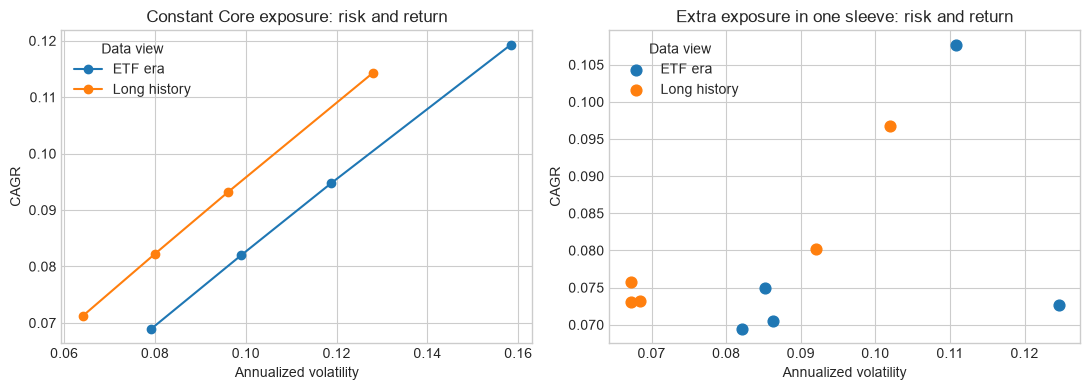

In [15]:
frontier=[]; sleeve=[]
for dataset,p in primary_panels.items():
    for e in (1.0,1.25,1.5,2.0):
        r=economic(p['Core'],p['RF'],e); s=metrics(r,p['RF'],p['Core'])
        frontier.append({'dataset':dataset,'exposure':e,**s.to_dict()})
    for asset in ASSETS:
        r=p['Core']+WEIGHTS[asset]*(p[asset]-p['RF']); s=metrics(r,p['RF'],p['Core'])
        sleeve.append({'dataset':dataset,'doubled sleeve':asset,**s.to_dict()})
frontier=pd.DataFrame(frontier); sleeve=pd.DataFrame(sleeve)
frontier_reader=frontier.copy(); frontier_reader['Sample']=frontier_reader['dataset'].map(SAMPLE_SHORT)
frontier_reader=frontier_reader[['Sample','exposure','CAGR','AnnVol','MaxDD','Calmar']].rename(columns={'exposure':'Constant Core exposure','AnnVol':'Annualized volatility','MaxDD':'Max drawdown'})
sleeve_reader=sleeve.copy(); sleeve_reader['Sample']=sleeve_reader['dataset'].map(SAMPLE_SHORT)
sleeve_reader=sleeve_reader[['Sample','doubled sleeve','CAGR','AnnVol','Sharpe','MaxDD','Information Ratio']].rename(columns={'doubled sleeve':'Sleeve receiving extra exposure','AnnVol':'Annualized volatility','MaxDD':'Max drawdown','Information Ratio':'Information Ratio vs 1x Core'})
display(frontier_reader.rename(columns={'Sample':'Data view'}).round(4))
display(sleeve_reader.rename(columns={'Sample':'Data view'}).round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for dataset,g in frontier.groupby('dataset'): axes[0].plot(g['AnnVol'],g['CAGR'],marker='o',label=SAMPLE_SHORT[dataset])
for dataset,g in sleeve.groupby('dataset'): axes[1].scatter(g['AnnVol'],g['CAGR'],label=SAMPLE_SHORT[dataset],s=60)
axes[0].set(title='Constant Core exposure: risk and return',xlabel='Annualized volatility',ylabel='CAGR'); axes[0].legend(title='Data view')
axes[1].set(title='Extra exposure in one sleeve: risk and return',xlabel='Annualized volatility',ylabel='CAGR'); axes[1].legend(title='Data view'); plt.tight_layout(); plt.show()

## Appendix — data provenance and reproducibility

The analysis uses the three data files bundled beside this notebook: a long-history monthly return snapshot, raw three-month Treasury-bill observations, and ETF month-end adjusted closes.

The long-history columns use ETF tickers as **asset-class role labels**, not as a claim that those ETFs existed throughout 1993–2025. The upstream economic series include Federal Reserve Treasury yields, Kenneth French research data, and World Bank monthly commodity data. Treasury returns are modeled economic proxies derived from yield changes with par-bond duration and convexity approximations.

The bundled long-history snapshot does not contain every ticker-to-source mapping, calibration coefficient, or splice step required to reconstruct it from raw upstream series. That is an important reproducibility limitation. Proxy and index-like histories can also omit or approximate ETF fees, tracking differences, liquidity, taxes, and implementation frictions, so the long-history view is evidence about economic behavior rather than actual ETF adjusted-close history or standalone policy-adoption proof.


In [16]:
display(provenance)
print(
    'Long-history monthly-return coverage:',
    long_history_raw.index.min().date(), 'to', long_history_raw.index.max().date(),
)
print(
    'ETF-era adjusted-close coverage:',
    close_raw.index.min().date(), 'to', close_raw.index.max().date(),
)


,Public file,Contents
Input,,
Long-history monthly returns,long_history_monthly_returns.csv,Monthly asset-class proxy returns
Three-month Treasury-bill observations,three_month_treasury_rate.csv,Raw public rate observations
ETF-era month-end adjusted closes,etf_month_end_adjusted_close.csv,Month-end adjusted closes for the five ETFs


Long-history monthly-return coverage: 1993-11-30 to 2025-12-31
ETF-era adjusted-close coverage: 2010-01-31 to 2026-08-31
